In [1]:
#PACKAGES

#Load Key
import os
from dotenv import load_dotenv

load_dotenv()

assert os.getenv("GEMINI_API_KEY"), "API key not found"
print("API key loaded successfully")

#Initialize Gemini
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",
    temperature=0,
    google_api_key=os.getenv("GEMINI_API_KEY")
)

response = llm.invoke("Say hello")
print(response.content)

#LangGraph
from langchain_core.tools import tool
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langchain_core.messages import SystemMessage
from IPython.display import Image, display
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode

API key loaded successfully


/Users/pedroalexleite/Library/Python/3.9/lib/python/site-packages/google/api_core/_python_version_support.py:246: FutureWarning: You are using a non-supported Python version (3.9.6). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
/Users/pedroalexleite/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/pedroalexleite/Library/Python/3.9/lib/python/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade

Hello there! How can I help you today?


In [2]:
#SPECIALIST TOOLS

@tool
def drug_lookup(drug_name: str) -> str:
    """Look up clinical information about a medication.
    Args:
        drug_name: The name of the drug (brand or generic)
    """
    
    drugs = {
        "warfarin": "Warfarin — Anticoagulant. Uses: blood clot prevention, atrial fibrillation. Side effects: bleeding, bruising.",
        "metformin": "Metformin — Biguanide. Uses: type 2 diabetes, insulin resistance. Side effects: nausea, diarrhea.",
        "lisinopril": "Lisinopril — ACE inhibitor. Uses: hypertension, heart failure. Side effects: dry cough, dizziness.",
        "insulin": "Insulin — Insulin analogue. Uses: type 1 & 2 diabetes. Side effects: hypoglycemia, weight gain.",
        "aspirin": "Aspirin — NSAID/Antiplatelet. Uses: pain relief, heart attack prevention. Side effects: stomach irritation, bleeding."
    }
    
    return drugs.get(drug_name.lower().strip(), f"Drug '{drug_name}' not found.")

@tool
def drug_interaction_checker(drug_a: str, drug_b: str) -> str:
    """Check if two drugs have known interactions.
    Args:
        drug_a: First drug name
        drug_b: Second drug name
    """
    
    interactions = {
        ("warfarin", "aspirin"): "HIGH RISK — Both increase bleeding risk. Avoid combination or monitor closely.",
        ("metformin", "insulin"): "MODERATE — Can cause hypoglycemia. Adjust doses carefully.",
        ("lisinopril", "aspirin"): "LOW RISK — May slightly reduce ACE inhibitor effectiveness.",
    }
    
    key1 = (drug_a.lower().strip(), drug_b.lower().strip())
    key2 = (drug_b.lower().strip(), drug_a.lower().strip())
    
    return interactions.get(key1, interactions.get(key2, f"No known interaction between {drug_a} and {drug_b}."))

@tool
def symptom_checker(symptoms: str) -> str:
    """Check possible conditions based on symptoms.
    Args:
        symptoms: Comma-separated symptoms (e.g., 'chest pain, fatigue')
    """
    
    condition_map = {
        "chest pain": ["Myocardial Infarction (I21)", "Angina Pectoris (I20)", "GERD (K21)"],
        "shortness of breath": ["Asthma (J45)", "Heart Failure (I50)", "COPD (J44)"],
        "frequent urination": ["Type 2 Diabetes (E11)", "UTI (N39.0)"],
        "blurred vision": ["Diabetic Retinopathy (E11.3)", "Glaucoma (H40)"],
        "fatigue": ["Anemia (D64.9)", "Hypothyroidism (E03)", "Depression (F32)"],
        "headache": ["Tension Headache (G44.2)", "Migraine (G43)", "Hypertension (I10)"]
    }
    
    results = []
    for s in symptoms.split(","):
        s = s.strip().lower()
        if s in condition_map:
            results.extend(condition_map[s])
            
    return f"Possible conditions: {', '.join(results)}" if results else f"No matches for: {symptoms}"

@tool
def condition_info(condition: str) -> str:
    """Get information about a medical condition.
    Args:
        condition: The name of the condition
    """
    
    conditions = {
        "diabetes": "Diabetes Mellitus — Chronic metabolic disorder. Types: Type 1, Type 2, Gestational. Key marker: HbA1c > 6.5%.",
        "hypertension": "Hypertension — Chronic elevated blood pressure (>140/90 mmHg). Risk factor for stroke, MI, kidney disease.",
        "asthma": "Asthma — Chronic airway inflammation. Symptoms: wheezing, cough, chest tightness.",
        "copd": "COPD — Progressive lung disease. Includes emphysema and chronic bronchitis. Main cause: smoking.",
        "heart failure": "Heart Failure — Heart can't pump enough blood. Symptoms: fatigue, edema, shortness of breath."
    }
    
    return conditions.get(condition.lower().strip(), f"No info found for '{condition}'.")

@tool
def interpret_lab_result(test_name: str, value: float) -> str:
    """Interpret a specific lab result value.
    Args:
        test_name: Name of the lab test
        value: The numeric result value
    """
    
    if test_name.lower() == "glucose":
        if value < 70: return f"Glucose {value} mg/dL — LOW (hypoglycemia)."
        elif value <= 100: return f"Glucose {value} mg/dL — NORMAL."
        elif value <= 125: return f"Glucose {value} mg/dL — PRE-DIABETIC."
        else: return f"Glucose {value} mg/dL — DIABETIC RANGE."
    elif test_name.lower() == "hba1c":
        if value < 5.7: return f"HbA1c {value}% — NORMAL."
        elif value <= 6.4: return f"HbA1c {value}% — PRE-DIABETIC."
        else: return f"HbA1c {value}% — DIABETIC."
    elif test_name.lower() == "hemoglobin":
        if value < 12: return f"Hemoglobin {value} g/dL — LOW. Possible anemia."
        elif value <= 17.5: return f"Hemoglobin {value} g/dL — NORMAL."
        else: return f"Hemoglobin {value} g/dL — HIGH."
            
    return f"Cannot interpret {test_name} = {value}."

In [3]:
#SPECIALIST AGENTS

@tool
def medication_specialist(query: str) -> str:
    """Consult the medication specialist for questions about drugs,
    prescriptions, side effects, or drug interactions.
    Args:
        query: The medication-related question to answer
    """
    
    #this agent has its own tools and runs its own ReAct loop
    medication_llm = llm.bind_tools([drug_lookup, drug_interaction_checker])
    
    messages = [
        SystemMessage(content="You are a medication specialist. Use your tools to answer. Be concise."),
        HumanMessage(content=query)
    ]
    
    #manual ReAct loop for this specialist
    for _ in range(5): 
        response = medication_llm.invoke(messages)
        messages.append(response)
        
        if not response.tool_calls:
            return response.content
        
        #execute tool calls
        for tc in response.tool_calls:
            tool_map = {"drug_lookup": drug_lookup, "drug_interaction_checker": drug_interaction_checker}
            result = tool_map[tc["name"]].invoke(tc["args"])
            from langchain_core.messages import ToolMessage
            messages.append(ToolMessage(content=result, tool_call_id=tc["id"]))
    
    return "Could not resolve medication query."

@tool
def diagnosis_specialist(query: str) -> str:
    """Consult the diagnosis specialist for questions about symptoms,
    conditions, or diseases.
    Args:
        query: The diagnosis-related question to answer
    """
    
    diagnosis_llm = llm.bind_tools([symptom_checker, condition_info])
    
    messages = [
        SystemMessage(content="You are a diagnosis specialist. Use your tools to answer. Be concise."),
        HumanMessage(content=query)
    ]
    
    for _ in range(5):
        response = diagnosis_llm.invoke(messages)
        messages.append(response)
        
        if not response.tool_calls:
            return response.content
        
        for tc in response.tool_calls:
            tool_map = {"symptom_checker": symptom_checker, "condition_info": condition_info}
            result = tool_map[tc["name"]].invoke(tc["args"])
            from langchain_core.messages import ToolMessage
            messages.append(ToolMessage(content=result, tool_call_id=tc["id"]))
    
    return "Could not resolve diagnosis query."

@tool
def lab_specialist(query: str) -> str:
    """Consult the lab results specialist for questions about lab tests,
    blood work, or test interpretation.
    Args:
        query: The lab-related question to answer
    """
    
    lab_llm = llm.bind_tools([interpret_lab_result])
    
    messages = [
        SystemMessage(content="You are a lab results specialist. Use your tools to answer. Be concise."),
        HumanMessage(content=query)
    ]
    
    for _ in range(5):
        response = lab_llm.invoke(messages)
        messages.append(response)
        
        if not response.tool_calls:
            return response.content
        
        for tc in response.tool_calls:
            tool_map = {"interpret_lab_result": interpret_lab_result}
            result = tool_map[tc["name"]].invoke(tc["args"])
            from langchain_core.messages import ToolMessage
            messages.append(ToolMessage(content=result, tool_call_id=tc["id"]))
    
    return "Could not resolve lab query."

In [4]:
#SUPERVISOR

class State(TypedDict):
    messages: Annotated[list, add_messages]

#the supervisor's tools are the specialists themselves
supervisor_tools = [medication_specialist, diagnosis_specialist, lab_specialist]
supervisor_llm = llm.bind_tools(supervisor_tools)

SUPERVISOR_PROMPT = """You are a medical supervisor coordinating a team of specialists.
You have three specialists you can consult:

1. medication_specialist — for drug info, interactions, side effects
2. diagnosis_specialist — for symptoms, conditions, diseases
3. lab_specialist — for lab test interpretation and reference ranges

For complex questions, you may need to consult MULTIPLE specialists.
For example: "diabetic patient on metformin with glucose of 142" needs both 
the medication specialist and the lab specialist.

Think step by step:
1. What information do I need?
2. Which specialist(s) should I consult?
3. Do I need more info after getting the first result?
4. Synthesize all results into a clear answer.

Always consult at least one specialist before answering."""

def supervisor(state: State):
    messages = [SystemMessage(content=SUPERVISOR_PROMPT)] + state["messages"]
    response = supervisor_llm.invoke(messages)
    
    return {"messages": [response]}

Graph compiled!


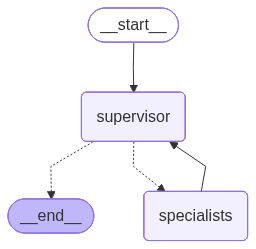

In [5]:
#BUILD, COMPILE AND VISUALIZE GRAPH

#the supervisor's tool node runs the specialist agents
supervisor_tool_node = ToolNode(tools=supervisor_tools)

def should_continue(state: State):
    last = state["messages"][-1]
    if last.tool_calls:
        return "specialists"
        
    return END

graph_builder = StateGraph(State)

#nodes
graph_builder.add_node("supervisor", supervisor)
graph_builder.add_node("specialists", supervisor_tool_node)

#edges
graph_builder.add_edge(START, "supervisor")
graph_builder.add_conditional_edges(
    "supervisor",
    should_continue,
    {"specialists": "specialists", END: END}
)
graph_builder.add_edge("specialists", "supervisor")  #loop back

graph = graph_builder.compile()
print("Graph compiled!")

#visualize
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())

In [6]:
#RUN AGENT

def run_agent(question: str):
    print(f"\n{'='*60}")
    print(f"Question: {question}")
    print(f"{'='*60}")
    
    events = graph.stream(
        {"messages": [HumanMessage(content=question)]},
        stream_mode="values"
    )
    
    for event in events:
        last_msg = event["messages"][-1]
        if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
            for tc in last_msg.tool_calls:
                print(f"  🔧 Consulting: {tc['name']}({tc['args']})")
        elif last_msg.type == "tool":
            print(f"  📋 Specialist Result: {last_msg.content[:300]}")
        elif last_msg.type == "ai" and last_msg.content:
            print(f"  🤖 Supervisor: {last_msg.content}")

In [7]:
#TESTS

run_agent("What are the side effects of warfarin?")
run_agent("My patient has chest pain. What could it be and what medications might help?")
run_agent("My diabetic patient is on metformin and has a glucose of 142 mg/dL. Should I be concerned?")
run_agent("Patient has fatigue, is on insulin, and has hemoglobin of 10 g/dL. What's going on?")
run_agent("Can I prescribe warfarin and aspirin together for a patient with atrial fibrillation?")


Question: What are the side effects of warfarin?
  🔧 Consulting: medication_specialist({'query': 'side effects of warfarin'})
  📋 Specialist Result: Warfarin is an anticoagulant used to prevent blood clots and treat atrial fibrillation. Side effects include bleeding and bruising.
  🤖 Supervisor: Warfarin is an anticoagulant used to prevent blood clots. Side effects include bleeding and bruising.

Question: My patient has chest pain. What could it be and what medications might help?
  🔧 Consulting: diagnosis_specialist({'query': 'chest pain causes'})
  🔧 Consulting: medication_specialist({'query': 'chest pain treatment'})


Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised ResourceExhausted: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details..


  📋 Specialist Result: I am sorry, I cannot provide medical advice. I can provide information on medications if you give me a drug name.
  🤖 Supervisor: Chest pain can be caused by Myocardial Infarction, Angina Pectoris, or GERD. I can't recommend specific medications without more information, but if you provide a specific drug name, I can offer information.

Question: My diabetic patient is on metformin and has a glucose of 142 mg/dL. Should I be concerned?
  🔧 Consulting: medication_specialist({'query': 'metformin for diabetes'})
  🔧 Consulting: lab_specialist({'query': 'glucose 142 mg/dL diabetic'})
  📋 Specialist Result: Glucose 142.0 mg/dL is in the diabetic range.
  🤖 Supervisor: Yes, you should be concerned. A glucose level of 142 mg/dL is in the diabetic range, even though the patient is on metformin. This suggests that the patient's diabetes may not be well controlled with the current metformin dosage. You may want to consider adjusting the medication or adding another diabete